# Atividade 07 — Reamostragem (CV + Bootstrap)

**Script R equivalente:** [`../scriptsR/07-reamostragem.R`](../scriptsR/07-reamostragem.R)

**Explicação detalhada (consolidado):** [consolidado/07-reamostragem.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/07-reamostragem.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo:** `mortalidade_60_69`. Predictor: `escolaridade`.

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [1]:
# =============================================================
# SETUP — Atividade 07
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade nao requer pacotes externos.

options(repr.plot.width = 8, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

[INFO] Setup concluido.


In [2]:
# =============================================================
# DADOS — Atividade 07
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"
origem_dados <- if (file.exists(arquivo_local)) arquivo_local else url_github
if (file.exists(arquivo_local)) cat("[INFO] Carregando banco LOCAL.\n") else cat("[INFO] Carregando do GitHub.\n")

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  escolaridade      = as.numeric(dados_brutos[[6]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]])
)

n <- nrow(dados); k <- 5
mse_fun <- function(y, yh) mean((y - yh)^2)

cat("[INFO] Dados carregados:", n, "linhas.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas.


In [3]:
# =============================================================
# ANALISE — Atividade 07
# =============================================================
cv_grau <- function(g, k = 5, seed = 1) {
  set.seed(seed)
  d <- sample(rep(1:k, length = n))
  errs <- sapply(1:k, function(j) {
    tr <- dados[d != j, ]; te <- dados[d == j, ]
    m  <- lm(mortalidade_60_69 ~ poly(escolaridade, g), data = tr)
    mse_fun(te$mortalidade_60_69, predict(m, newdata = te))
  })
  list(mean = mean(errs), dobras = errs)
}

graus <- c(1, 3, 12)
cvs <- lapply(graus, cv_grau); names(cvs) <- paste0("grau_", graus)

cat("\n================ CV(5) - GRAUS 1, 3, 12 ================\n")
print(data.frame(
  Candidato = names(cvs),
  RMSE_CV = round(sqrt(sapply(cvs, `[[`, "mean")), 4)
))
cat("sd(Y) =", round(sd(dados$mortalidade_60_69), 4), "\n")

cat("\n--- Erro por dobra ---\n")
tab_dobras <- data.frame(Dobra = 1:k)
for (i in seq_along(graus)) tab_dobras[[names(cvs)[i]]] <- round(sqrt(cvs[[i]]$dobras), 4)
print(tab_dobras)

# 6 splits avulsos para comparar volatilidade
set.seed(1)
curvas_av <- lapply(1:6, function(r) {
  d <- sample(rep(1:k, length = n))
  sapply(graus, function(g) {
    errs <- sapply(1:k, function(j) {
      tr <- dados[d != j, ]; te <- dados[d == j, ]
      m  <- lm(mortalidade_60_69 ~ poly(escolaridade, g), data = tr)
      mse_fun(te$mortalidade_60_69, predict(m, newdata = te))
    })
    mean(errs)
  })
})

# Bootstrap de beta1
B <- 2000; set.seed(1)
b1_boot <- replicate(B, {
  i <- sample(n, n, replace = TRUE)
  coef(lm(mortalidade_60_69 ~ escolaridade, data = dados[i, ]))["escolaridade"]
})
m_orig <- lm(mortalidade_60_69 ~ escolaridade, data = dados)
b1_hat <- coef(m_orig)["escolaridade"]
se_class <- summary(m_orig)$coef["escolaridade", "Std. Error"]
se_boot <- sd(b1_boot)
ci_boot <- quantile(b1_boot, c(0.025, 0.975))
ci_class <- confint(m_orig)["escolaridade", ]

cat("\n================ BOOTSTRAP beta1 ================\n")
cat("beta1 MQO:      ", round(b1_hat, 4), "\n")
cat("EP analitico:   ", round(se_class, 4), "\n")
cat("EP bootstrap:   ", round(se_boot, 4), "\n")
cat("IC 95% analitico: [", round(ci_class[1], 4), ";", round(ci_class[2], 4), "]\n")
cat("IC 95% bootstrap: [", round(ci_boot[1], 4), ";", round(ci_boot[2], 4), "]\n")
cat("0 dentro do IC bootstrap?",
    ifelse(ci_boot[1] <= 0 && 0 <= ci_boot[2], "SIM", "NAO"), "\n")


================ CV(5) - GRAUS 1, 3, 12 ================
        Candidato  RMSE_CV
grau_1     grau_1   3.8945
grau_3     grau_3   3.9420
grau_12   grau_12 239.9973
sd(Y) = 3.8504 

--- Erro por dobra ---
  Dobra grau_1 grau_3  grau_12
1     1 2.9083 2.9805   3.1015
2     2 3.9910 4.0575  16.7908
3     3 4.4839 4.4775   4.0139
4     4 4.8409 4.7836   5.2158
5     5 2.8124 3.0694 536.3383

================ BOOTSTRAP beta1 ================
beta1 MQO:       -2.0959 
EP analitico:    8.5337 
EP bootstrap:    7.9221 
IC 95% analitico: [ -19.2201 ; 15.0283 ]
IC 95% bootstrap: [ -18.8741 ; 11.8109 ]
0 dentro do IC bootstrap? SIM 


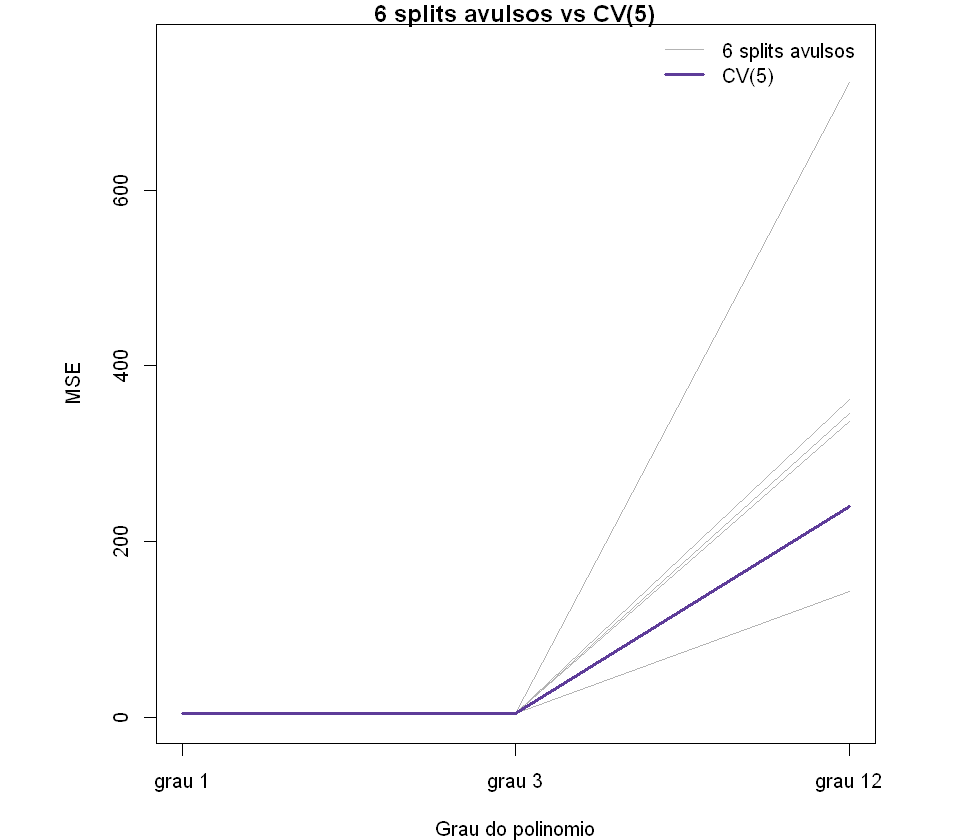

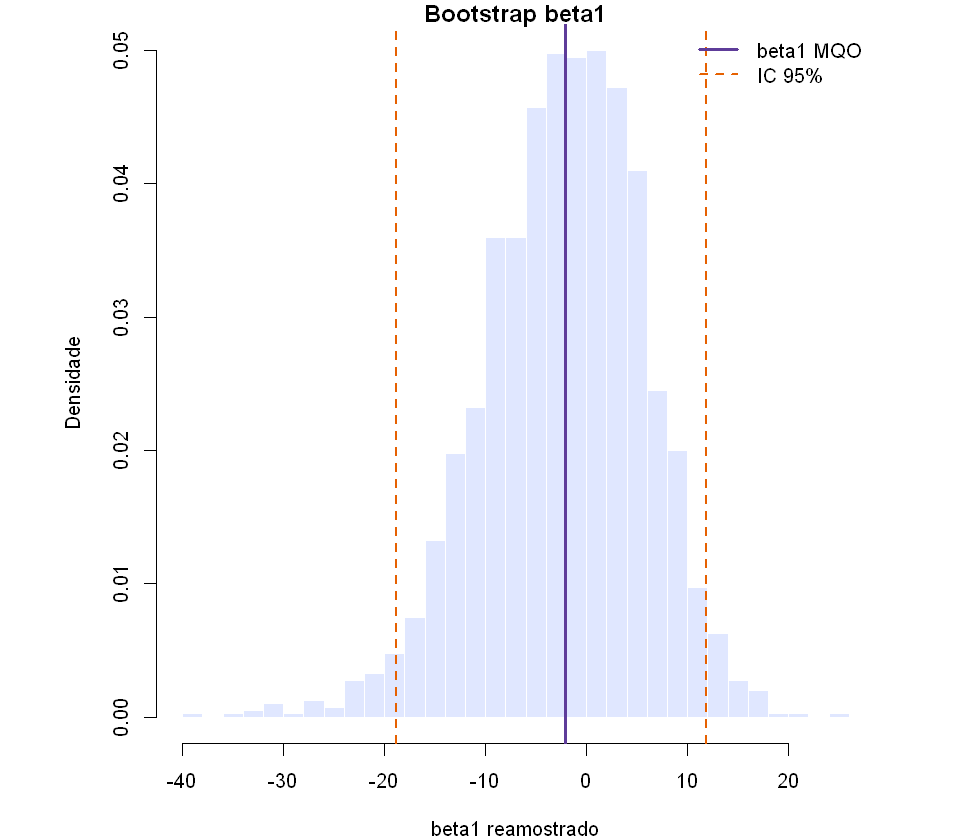

In [4]:
# =============================================================
# GRAFICOS — Atividade 07
# =============================================================
cazul <- "#276DC3"; claranja <- "#E66101"; croxo <- "#5E3C99"; cfill <- "#E0E7FF"

# Grafico 1 — 6 splits avulsos vs CV(5)
par(mar = c(4,4,1,1), pty = "s")
ymax <- max(sqrt(unlist(curvas_av))) * 1.05
plot(seq_along(graus), sqrt(sapply(cvs, `[[`, "mean")), type = "l", lwd = 3, col = croxo,
     ylim = c(0, ymax), xaxt = "n", xlab = "Grau do polinomio", ylab = "MSE",
     main = "6 splits avulsos vs CV(5)")
axis(1, at = seq_along(graus), labels = paste0("grau ", graus))
for (r in seq_along(curvas_av))
  lines(seq_along(graus), sqrt(curvas_av[[r]]), col = "gray70", lwd = 1.5)
lines(seq_along(graus), sqrt(sapply(cvs, `[[`, "mean")), col = croxo, lwd = 3)
legend("topright", c("6 splits avulsos","CV(5)"),
       col = c("gray70", croxo), lwd = c(1.5, 3), bty = "n")

# Grafico 2 — distribuicao bootstrap de beta1
par(mar = c(4,4,1,1), pty = "s")
hist(b1_boot, breaks = 30, prob = TRUE, col = cfill, border = "white",
     xlab = "beta1 reamostrado", ylab = "Densidade", main = "Bootstrap beta1")
abline(v = ci_boot, col = claranja, lwd = 2, lty = 2)
abline(v = b1_hat, col = croxo, lwd = 3)
legend("topright", c("beta1 MQO","IC 95%"),
       col = c(croxo,claranja), lwd = c(3,2), lty = c(1,2), bty = "n")